<img src="https://drive.google.com/uc?export=view&id=1_TxtLd2mqSKnuwQwTV-py5Q55A6gB97d">

# Geodatabase Timeseries with the API

This notebook provides a step-by-step guide on utilizing the OpenET API's */geodatabase/metadata/ids* endpoint to retrieve field IDs contained within a specified region. Then make an additional query to the */geodatabase/timeseries* endpoint to get monthly evapotranspiration and precipitation data for all fields within

## To complete this notebook you will need:
1. [OpenET Account](https://account.etdata.org/login)
2. [OpenET API Key](https://account.etdata.org/settings/api)
3. A valid GeoJSON file. This demo uses the HUC-12 watershed boundary of the Little Shasta River.


To apply this same workflow for another region:
* Convert a shapefile to GeoJSON using **[MapShaper](https://mapshaper.org/)**
* Evaluate GeoJSON compatibility with OpenET data servicesusing **[GeoJSONLint](https://geojsonlint.com/)**





In [ ]:
#@title Import Python dependencies
import calendar
import getpass
import gzip
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import shapely
#  Download Lower Shasta River Boundary
!gdown 1JY_6p0boPPGfyoGIOYz31kyyH1NODtGG

Downloading...
From: https://drive.google.com/uc?id=1JY_6p0boPPGfyoGIOYz31kyyH1NODtGG
To: /content/workshop_llsr.geojson
100% 52.2k/52.2k [00:00<00:00, 13.1MB/s]


In [ ]:
#@title Configure your API Key to access OpenET data

# @markdown #### Go to your [OpenET API account](https://auth.etdata.org/dashboard) page and copy the API Key. { run: "auto" }

# @markdown #### Then paste your API Key below after running this cell

YOUR_API_KEY = getpass.getpass("Paste your API key here --> ")


header = {"Authorization": YOUR_API_KEY}

Paste your API key here --> ··········


In [ ]:
#@title Load boundary as GeoJSON
#@markdown In the files sidetab, you can right-click your file and select the option 'Copy path', which you can paste into the text field.

geojson_path = "/content/workshop_llsr.geojson" # @param {"type": "string", "placeholder": "Insert path here"}


In [ ]:
#@title Get shape from GeoJSON
# Read the GeoJSON
geojson = gpd.read_file(geojson_path)
# Extract the coordinates of the GeoJSON with shapely.get_coordinates to a list to pass to the API.
# The code flattens the matrix and puts the coordinates into a 1D list (format required for the API).
geometry = shapely.get_coordinates(geojson.geometry).flatten().tolist()

In [ ]:
#@title Retrieve Field IDs contained within GeoJSON

# This provides the API with your API key.
api_header = {"AUTHORIZATION": YOUR_API_KEY}
# This provides the parameters for the request.
api_query = {
    "geometry": geometry
}

# This is the request itself.
api_request = requests.post(
    url="https://openet-api.org/geodatabase/metadata/ids",
    headers=api_header,
    json=api_query
)

# Parse the response since it is compressed.
fields = eval(gzip.decompress(api_request.content).decode())

In [ ]:
#@title Retrieve metadata associated with the list of fields

# endpoint arguments
args = {
  "field_ids":fields
}

# query the api
resp = requests.post(
    headers=api_header,
    json=args,
    url="https://openet-api.org/geodatabase/metadata/properties"
)

# unzip the data
meta_data = eval(gzip.decompress(resp.content).decode())

In [ ]:
#@title Retrieve field geometries
geo_query = {
    "field_ids": fields,
}

geo_resp = requests.post(
    url="https://openet-api.org/geodatabase/metadata/boundaries",
    headers=api_header,
    json=geo_query
)

geometries = eval(gzip.decompress(geo_resp.content).decode())

In [ ]:

with open("field_boundaries.geojson", "w") as file:
    json.dump(geometries, file, indent=4)

fields_gdf = gpd.read_file("field_boundaries.geojson")



In [ ]:
#@title Retrieve monthly timeseries data for 2016-2024

api_query = {
    "field_ids": fields,
    "date_range": ["2016-01-01", "2024-12-31"],
    "interval": "monthly",
    "variables": ["et", "pr"],
    "models": ["ensemble"],
    "file_format": "JSON"
}

api_request = requests.post(
    url="https://openet-api.org/geodatabase/timeseries",
    headers=api_header,
    json=api_query
)

timeseries = eval(gzip.decompress(api_request.content).decode())

In [ ]:
#@title Read the timeseries data as a Pandas dataframe

#read dataframe from json
df_meta =pd.DataFrame.from_records(meta_data)[["field_id","hectares"]]
df_meta["acres"] = df_meta["hectares"]*0.404686
df = pd.DataFrame.from_records(timeseries)
df["time"] = pd.to_datetime(df["time"])

# separate et and precipitation then merge dataframes
et_df = df.query("collection == 'ensemble_et'")
et_df = et_df.drop(columns="collection").rename(columns={"value_mm": "et"})

pr_df = df.query("collection == 'gridmet_pr'")
pr_df = pr_df.drop(columns="collection").rename(columns={"value_mm": "pr"})

df = pd.merge(et_df, pr_df, how="inner", on=["field_id", "time"])
cols_to_convert = ["et", "pr"]
df[cols_to_convert] = df[cols_to_convert] / 25.4


df_all = pd.merge(df, df_meta[["field_id","acres"]], how="inner", on=["field_id"])


Calculate monthly ETn by max(0, ET-Pr) following:

While there are more advanced approaches. This method assumes:
* 100% of precipitation is during growing season
* minimal to 0 soil water carry over

In [ ]:
def calculate_etn(df):
    return max(0, df["et"] - df["pr"])

In [ ]:
df_all["etn"] = df_all.apply(calculate_etn, axis=1)
df_all.query("etn > 0").head()

,time,field_id,et,pr,acres,etn
184,2016-02-01,21106017688,1.162323,0.998976,9.285520,0.163346
185,2016-02-01,21106019847,1.265709,1.011693,8.001452,0.254016
187,2016-02-01,21106017099,1.134331,1.007480,1.440277,0.126850
188,2016-02-01,21106018393,1.248386,1.104646,78.014153,0.143740
189,2016-02-01,21106019806,1.231969,1.041693,5.299363,0.190276


The aggregated sums are in a new DataFrame 'etn_yearly_sums'.

In [ ]:
df_ss

,time,field_id,et,pr,acres,etn,month
3,2016-01-01,21106017450,0.490866,3.997087,1.831204,0.0,1
4,2016-01-01,21106017538,0.430866,3.644685,5.341855,0.0,1
5,2016-01-01,21106017541,0.408622,3.625630,11.814808,0.0,1
6,2016-01-01,21106017547,0.527677,3.662205,8.175871,0.0,1
7,2016-01-01,21106017581,0.530315,3.866102,22.507017,0.0,1
...,...,...,...,...,...,...,...
19430,2024-12-01,21106017866,0.588071,5.269055,5.081237,0.0,12
19431,2024-12-01,21106017899,0.438268,6.049370,4.194166,0.0,12
19432,2024-12-01,21106017908,0.558622,5.407835,2.572589,0.0,12
19433,2024-12-01,21106017937,0.507087,6.014646,12.556193,0.0,12


In [ ]:
#@title Subset fields based on list of field ids

#make synthetic list of field ids
# modify with ids from polygons.
list_of_field_ids = list(df_all.field_id.unique()[:])

#subset data
df_ss = df_all[df_all.field_id.isin(list_of_field_ids)].copy()
df_ss['month']=df_ss.time.dt.month
df_ss['year']=df_ss.time.dt.year

df_field_months = df_ss.groupby(['field_id','month'])[['etn']].mean().reset_index()

# #subset data by year < To Do
# df_field_months = df_ss.groupby(['field_id','month'])[['etn']].mean().reset_index()

pivot_df = df_field_months.pivot(index="field_id", columns="month", values="etn")


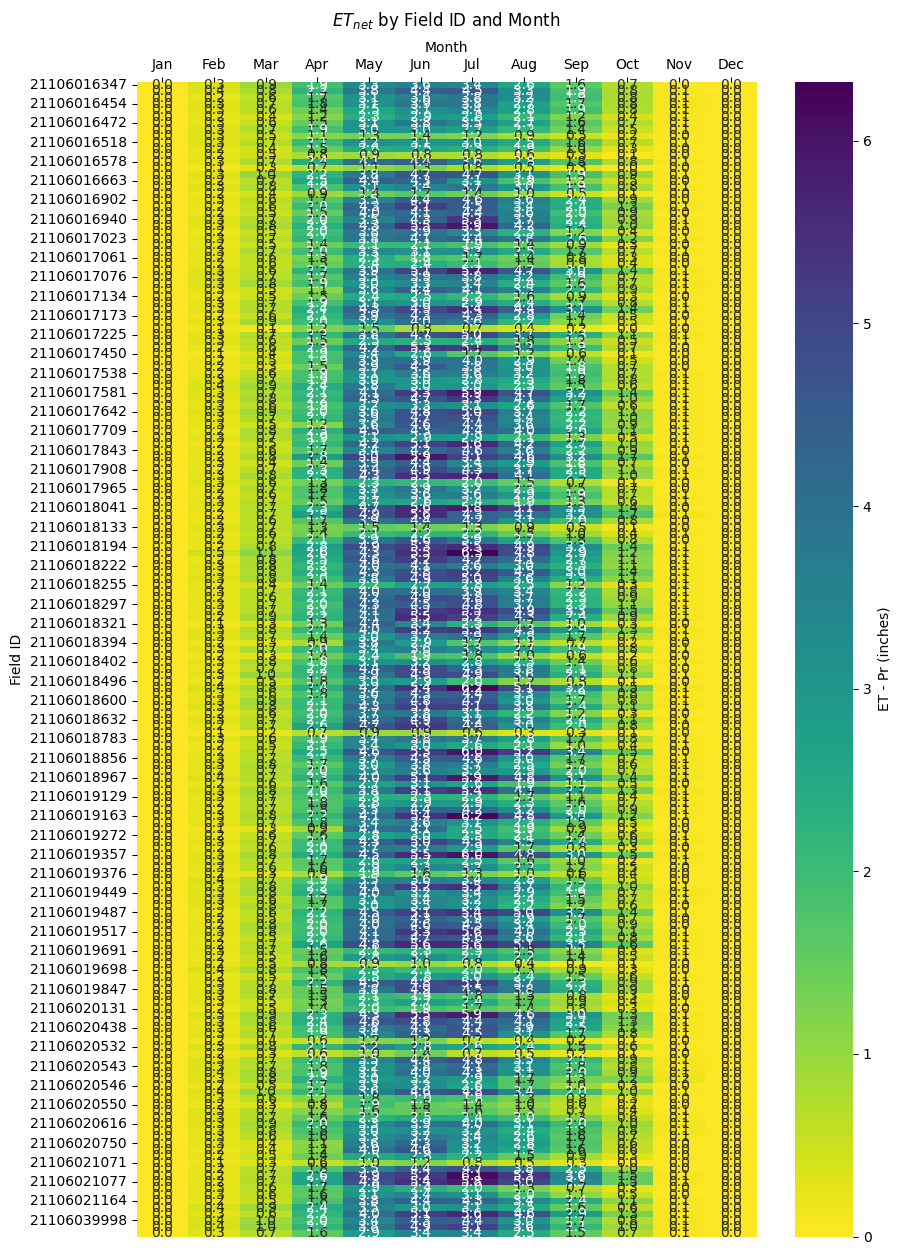

In [ ]:
#@title Create figure of seasonnal heat map of ETn
plt.figure(figsize=(10, 15))
ax = sns.heatmap(
    pivot_df,
    annot=True,
    cmap="viridis_r",
    # cmap="RdYlGn",
    fmt=".1f",
    cbar_kws={'label': 'ET - Pr (inches)'}
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
month_labels = [calendar.month_abbr[m] for m in pivot_df.columns]
ax.set_xticklabels(month_labels)

plt.title("$ET_{net}$ by Field ID and Month", pad=40)
plt.xlabel("Month")
plt.ylabel("Field ID")
plt.show()



<Axes: >

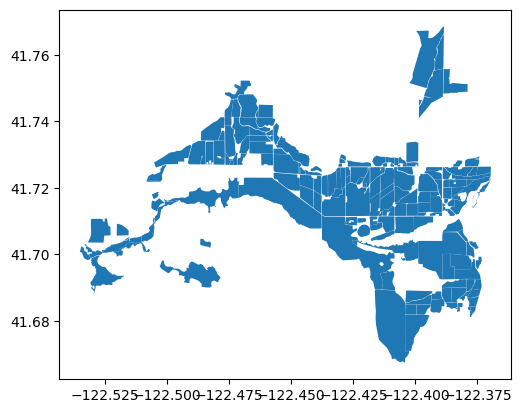

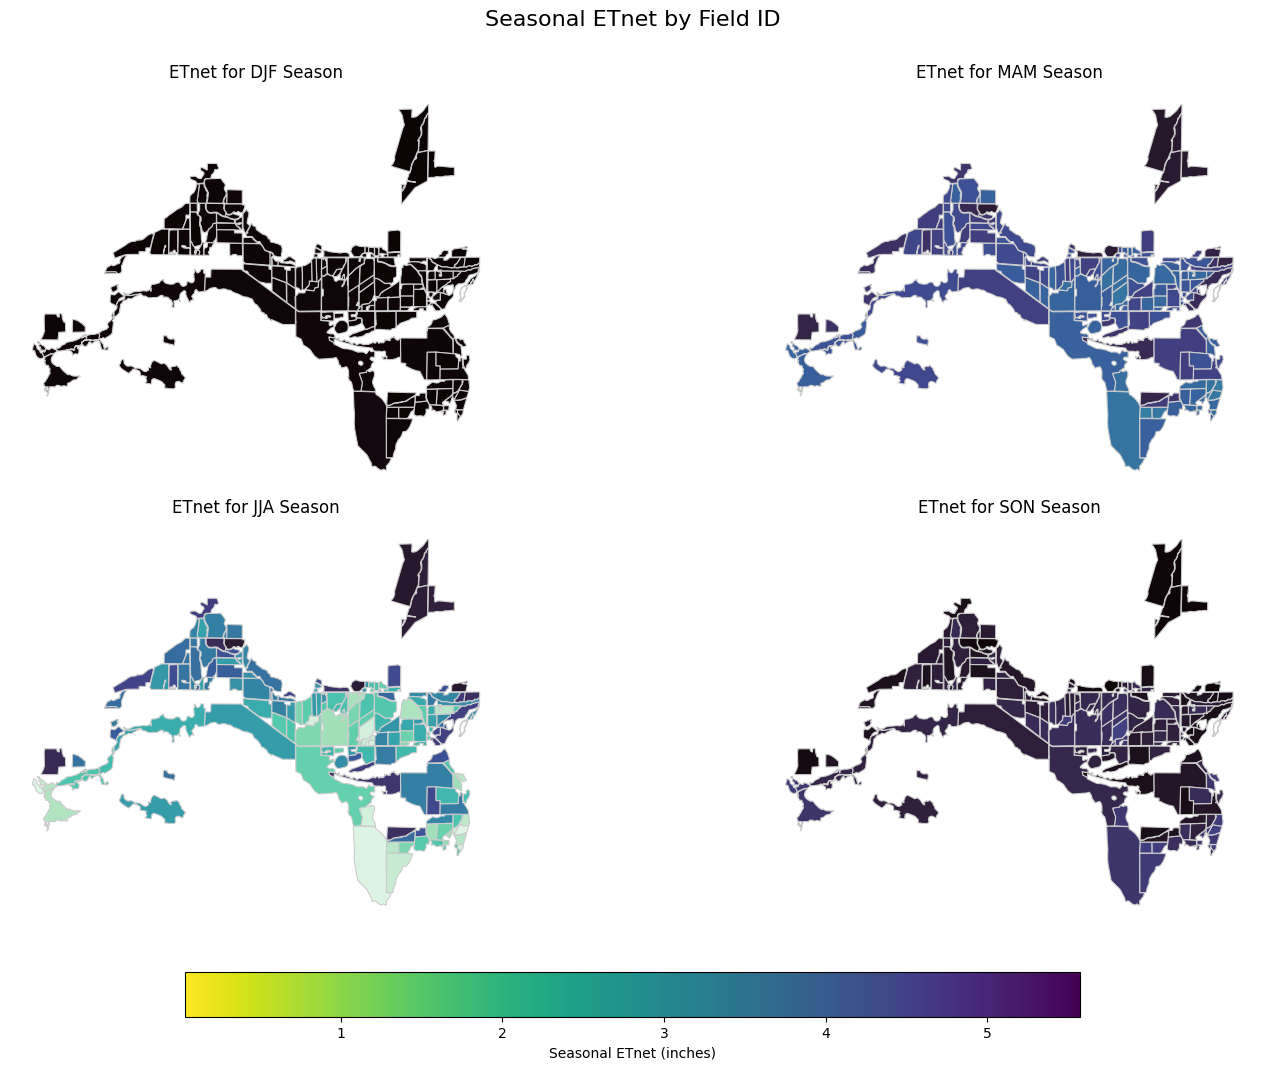

In [ ]:
merged_gdf = fields_gdf.merge(pivot_df.reset_index(), on='field_id', how='left')

# Define seasons
seasons = {
    'DJF': [12, 1, 2],  # December, January, February
    'MAM': [3, 4, 5],   # March, April, May
    'JJA': [6, 7, 8],   # June, July, August
    'SON': [9, 10, 11]  # September, October, November
}

# Calculate seasonal means and store in new columns
for season_name, months in seasons.items():
    # Handle DJF by considering month 12 as part of the winter season starting in the previous year
    # For simplicity, we are taking the mean of the specified months from the pivot_df
    # Assuming the pivot_df already contains the 'etn' values for these months
    merged_gdf[f'etn_{season_name}'] = merged_gdf[months].mean(axis=1)


# Plotting by season
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

# Determine common vmin and vmax for all plots
all_etn_values = []
for season_name, _ in seasons.items():
    all_etn_values.extend(merged_gdf[f'etn_{season_name}'].dropna().tolist())

vmin = min(all_etn_values) if all_etn_values else 0
vmax = max(all_etn_values) if all_etn_values else 1 # Avoid division by zero if all_etn_values is empty

for i, (season_name, months) in enumerate(seasons.items()):
    ax = axes[i]
    merged_gdf.plot(
        column=f'etn_{season_name}',
        cmap='mako_r',
        linewidth=0.8,
        ax=ax,
        edgecolor='0.8',
        legend=False, # Set to False to prevent individual colorbars
        vmin=vmin, # Apply common vmin
        vmax=vmax # Apply common vmax
    )
    ax.set_title(f'ETnet for {season_name} Season')
    ax.set_axis_off()

# Add a single colorbar
cbar = fig.colorbar(
        cmap='mako_r',
    plt.cm.ScalarMappable(cmap='', norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    shrink=0.6,
    pad=0.05
)
cbar.set_label('Seasonal ETnet (inches)')

plt.suptitle('Seasonal ETnet by Field ID', fontsize=16, y=1.05)
plt.show()